# GOLDEN 06_dominance

**Thesis section:** `sec:results:dominance`  
**Provenance:** Dominance. Ported verbatim from scripts/build_nb_034.py (superseded).  
**Data:** results/mas/final_dataset_new_system  
**Figures exported to:** thesis/plots/dominance/ (fig1_D_distribution .. fig4_D_accuracy)  
**Status:** reproducible from committed data.

This is a GOLDEN notebook: it recomputes every number in the named thesis section from raw data and exports every figure to the fixed `thesis/plots/` path the LaTeX already includes. Numbers are printed in labelled blocks for manual copy into the thesis. See `notebooks/golden/INDEX.md` for the full section->notebook map.


# 034 — Dominance Analysis (new_system dataset, R=50)

Full dominance analysis on `results/mas/final_dataset_new_system`.
35 tasks × 6 configs × 2 datasets = 420 cells, R=50 reps each.

Figures exported to `thesis/plots/dominance/`.

Key design decisions carried forward:
- FC only for z/flag (star null is degenerate for >80% of reps due to forced leaf→centre conversions)
- Raw D reported for both topologies
- Task-level aggregation for cluster-robust inference


In [1]:
import sys
sys.path.insert(0, '../..')

import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.dominance import analyse_dominance, _influence_graph
from src.metrics.stats_utils import (
    task_paired_wilcoxon, task_one_sample_wilcoxon, task_sign_test,
    task_spearman, bh_fdr,
)

BASE   = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
EXPORT = Path('../..') / 'thesis' / 'plots' / 'dominance'
EXPORT.mkdir(parents=True, exist_ok=True)

W_VALUES = [1, 2, 5]
TOPOS    = ['fc', 'star']
DATASETS = ['gpqa', 'hiddenbench']
Z_FLAG_TOPO = 'fc'

from src.viz.thesis_style import (apply_style, W_COLORS, DS_COLORS, T_COLORS,
                                   DS_LABELS, T_LABELS, ABBR)

apply_style()
print('setup ok')

/Users/I550854/Documents/Master Thesis/self-organization-mas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


setup ok


In [2]:
# ── Load and run dominance analysis ──────────────────────────────────────────
cell_rows = []
rep_rows  = []

t0 = time.time()
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']
    M    = len(d['options'])
    N    = reps[0]['N']
    accuracy = float(np.mean([rep['correct'] for rep in reps]))

    rep_results = [analyse_dominance(rep, B=1000, seed=42) for rep in reps]

    valid    = [r for r in rep_results if r is not None]
    testable = [r for r in valid if r['testable']]
    Ds       = [r['D'] for r in valid]
    zs       = [r['z'] for r in testable]
    flags    = [r['flagged'] for r in testable]

    cell_rows.append({
        'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
        'ground_truth': gt, 'M': M, 'N': N, 'accuracy': accuracy,
        'n_reps': len(rep_results), 'n_valid': len(valid),
        'n_excluded': len(rep_results) - len(valid),
        'n_testable': len(testable), 'n_degenerate': len(valid) - len(testable),
        'D_mean': float(np.mean(Ds)) if Ds else np.nan,
        'D_median': float(np.median(Ds)) if Ds else np.nan,
        'z_mean': float(np.mean(zs)) if zs else np.nan,
        'flagged_fraction': float(np.mean(flags)) if flags else np.nan,
    })

    for rep_idx, (rep, r) in enumerate(zip(reps, rep_results)):
        if r is None:
            continue
        rep_rows.append({
            'dataset': ds, 'topology': topo, 'W': W, 'qid': qid, 'rep_idx': rep_idx,
            'M': M, 'correct': rep.get('correct', None),
            'D': r['D'],
            'z': r['z'],
            'p_value': r['p_value'],
            'testable': r['testable'],
            'flagged': r['flagged'],
            'hub': r['hub'],
            'hub_p': r['p'][r['hub']],
            'hub_is_consensus': r['hub_is_consensus'],
            'hub_capitulation': r['hub_capitulation'],
            'hub_correct': rep['trajectory'][-1]['phase_b'][r['hub']]['vote'] == gt,
        })

elapsed = time.time() - t0
df     = pd.DataFrame(cell_rows)
df_rep = pd.DataFrame(rep_rows)

df_task = (df_rep.groupby(['dataset','topology','W','qid'])
           .agg(D=('D','mean'),
                flagged=('flagged','mean'),
                z=('z','mean'),
                hub_p=('hub_p','mean'),
                hub_is_consensus=('hub_is_consensus','mean'),
                hub_capitulation=('hub_capitulation','mean'),
                n_testable=('testable','sum'))
           .reset_index())

print(f'Done in {elapsed:.1f}s  |  cells: {len(df)}  |  rep records: {len(df_rep)}')
print(f'Excluded (no conversions): {df["n_excluded"].sum()} / {df["n_reps"].sum()}')
print(f'Testable / valid         : {df["n_testable"].sum()} / {df["n_valid"].sum()}'
      f'  ({100*df["n_testable"].sum()/df["n_valid"].sum():.0f}%)')
print()
print('=== Accounting per (dataset, topology) ===')
for ds in DATASETS:
    for topo in TOPOS:
        s = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]
        c = df[(df['dataset']==ds) & (df['topology']==topo)]
        nv = len(s); nt = int(s['testable'].sum())
        nex = int(c['n_excluded'].sum())
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: valid={nv}  excl={nex}  testable={nt}'
              f'  ({100*nt/max(nv,1):.0f}%)')

Done in 672.9s  |  cells: 420  |  rep records: 17801
Excluded (no conversions): 3199 / 21000
Testable / valid         : 8769 / 17801  (49%)

=== Accounting per (dataset, topology) ===
  GPQA         fc   : valid=3977  excl=1273  testable=2844  (72%)
  GPQA         star : valid=3966  excl=1284  testable=497  (13%)
  HiddenBench  fc   : valid=4926  excl=324  testable=4073  (83%)
  HiddenBench  star : valid=4932  excl=318  testable=1355  (27%)


---
## Part 1 — Raw D distribution and topology comparison

In [3]:
print('=== Mean raw D by (dataset, topology, W) ===')
pivot_D = df_rep.groupby(['dataset','topology','W'])['D'].mean().unstack()
print(pivot_D.round(3).to_string())

print()
print('=== TOPOLOGY effect: star vs fc (paired Wilcoxon, task-level) ===')
def _sig(p): return '***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
for ds in DATASETS:
    for w in W_VALUES:
        fc = df_task[(df_task.dataset==ds)&(df_task.topology=='fc')  &(df_task.W==w)].set_index('qid')['D']
        st = df_task[(df_task.dataset==ds)&(df_task.topology=='star')&(df_task.W==w)].set_index('qid')['D']
        c = fc.index.intersection(st.index)
        stat, p = sp_stats.wilcoxon(st[c], fc[c])
        ratio = st[c].mean() / fc[c].mean() if fc[c].mean() > 0 else float('nan')
        print(f'  {DS_LABELS[ds]:12s} W={w}: fc={fc[c].mean():.3f}  star={st[c].mean():.3f}'
              f'  (x{ratio:.1f})  {_sig(p)} (p={p:.1e})')

=== Mean raw D by (dataset, topology, W) ===
W                         1      2      5
dataset     topology                     
gpqa        fc        0.147  0.155  0.154
            star      0.609  0.600  0.610
hiddenbench fc        0.158  0.179  0.178
            star      0.529  0.562  0.562

=== TOPOLOGY effect: star vs fc (paired Wilcoxon, task-level) ===
  GPQA         W=1: fc=0.143  star=0.625  (x4.4)  *** (p=5.8e-11)
  GPQA         W=2: fc=0.154  star=0.617  (x4.0)  *** (p=5.8e-11)
  GPQA         W=5: fc=0.147  star=0.639  (x4.3)  *** (p=5.8e-11)
  HiddenBench  W=1: fc=0.158  star=0.532  (x3.4)  *** (p=5.8e-11)
  HiddenBench  W=2: fc=0.180  star=0.564  (x3.1)  *** (p=5.8e-11)
  HiddenBench  W=5: fc=0.177  star=0.565  (x3.2)  *** (p=5.8e-11)


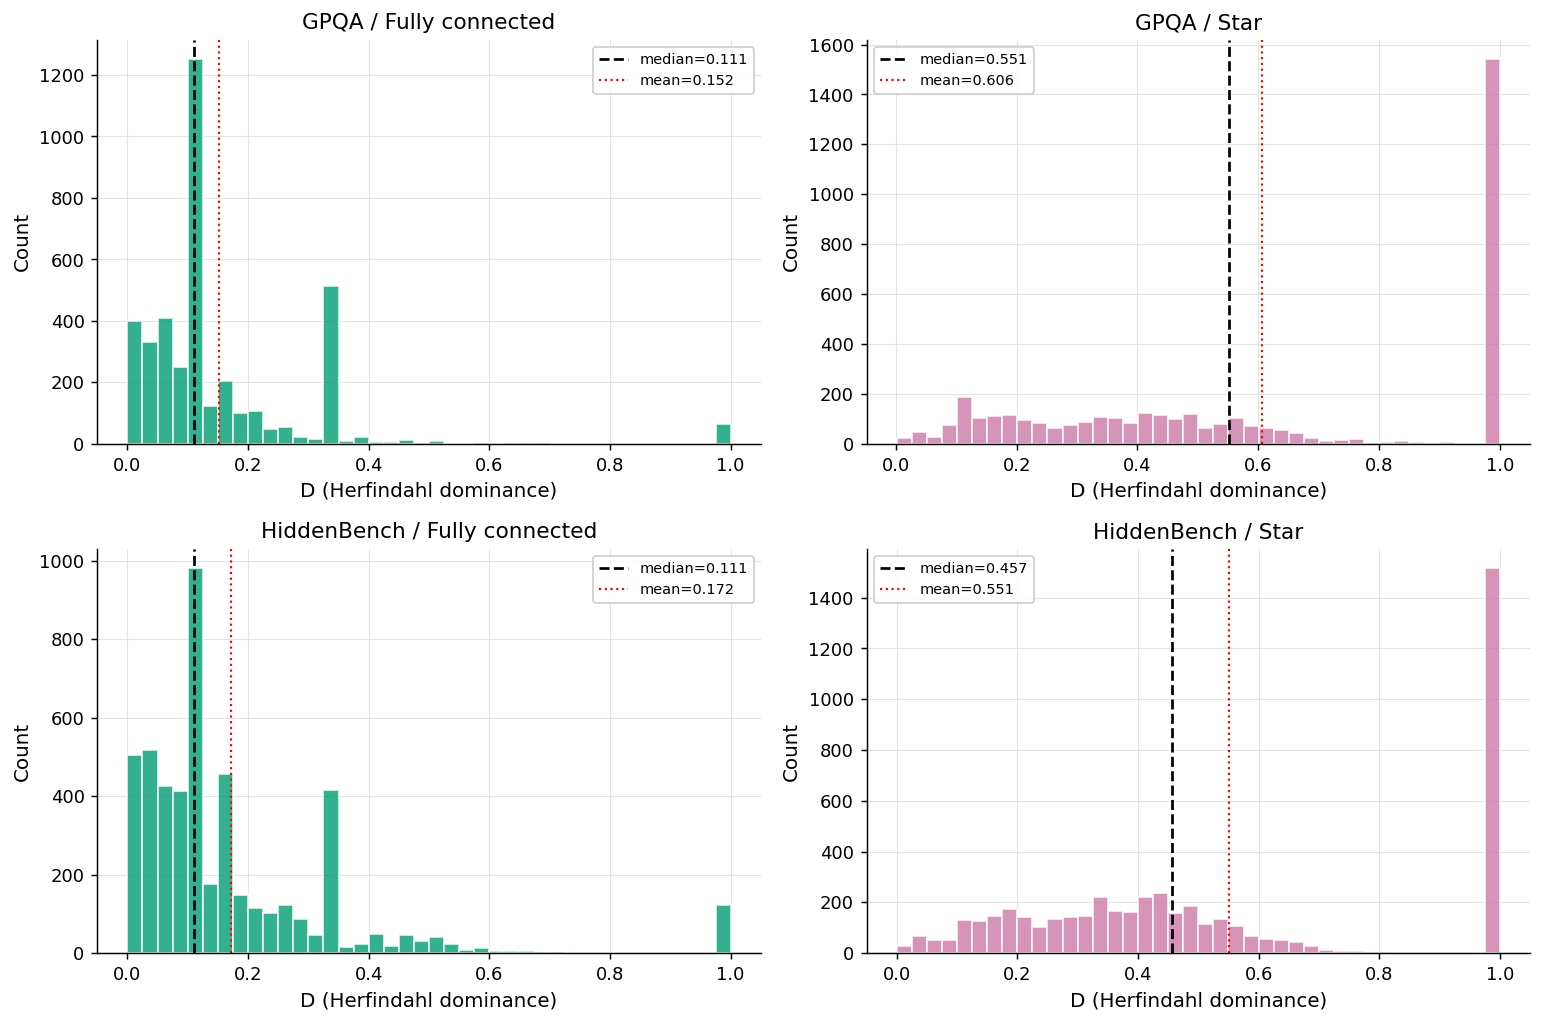

fig1 saved


In [4]:
# Fig 1 — D distribution by topology + dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax = axes[row, col]
        sub = df_rep[(df_rep['dataset']==ds) & (df_rep['topology']==topo)]['D']
        ax.hist(sub, bins=40, color=T_COLORS[topo], edgecolor='white', alpha=0.8)
        ax.axvline(sub.median(), color='black', linestyle='--', lw=1.5,
                   label=f'median={sub.median():.3f}')
        ax.axvline(sub.mean(),   color='red',   linestyle=':',  lw=1.2,
                   label=f'mean={sub.mean():.3f}')
        ax.set_xlabel('D (Herfindahl dominance)')
        ax.set_ylabel('Count')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(EXPORT / 'fig1_D_distribution.png')
plt.show()
print('fig1 saved')

---
## Part 2 — Emergent excess in FC (z-score test)

In [5]:
print(f'=== Emergent excess in {Z_FLAG_TOPO.upper()}: z > 0? ===')
print('(star null degenerate for >80% reps -> FC only)')
print()
for ds in DATASETS:
    for w in W_VALUES:
        z = df_rep[(df_rep.dataset==ds)&(df_rep.topology==Z_FLAG_TOPO)
                   &(df_rep.W==w)&(df_rep.testable)]['z'].dropna()
        stat, p = sp_stats.wilcoxon(z, alternative='greater')
        print(f'  {DS_LABELS[ds]:12s} W={w}: mean_z={z.mean():+.3f}  '
              f'median={z.median():+.3f}  {_sig(p)} (p={p:.1e})  n={len(z)}')

print()
print('=== Flag rate vs 5% baseline (FC, testable) ===')
for ds in DATASETS:
    s = df_rep[(df_rep.dataset==ds)&(df_rep.topology==Z_FLAG_TOPO)&(df_rep.testable)]['flagged']
    k, n = int(s.sum()), len(s)
    p = sp_stats.binomtest(k, n, 0.05, alternative='greater').pvalue
    print(f'  {DS_LABELS[ds]:12s}: flagged={k}/{n}={k/n:.3f}  vs 5%  {_sig(p)} (p={p:.1e})')

=== Emergent excess in FC: z > 0? ===
(star null degenerate for >80% reps -> FC only)

  GPQA         W=1: mean_z=+0.528  median=+0.445  *** (p=1.2e-24)  n=934
  GPQA         W=2: mean_z=+0.529  median=+0.317  *** (p=8.7e-27)  n=946
  GPQA         W=5: mean_z=+0.547  median=+0.494  *** (p=1.8e-29)  n=964
  HiddenBench  W=1: mean_z=+0.641  median=+0.579  *** (p=1.2e-45)  n=1349
  HiddenBench  W=2: mean_z=+0.808  median=+0.992  *** (p=3.0e-71)  n=1375
  HiddenBench  W=5: mean_z=+0.800  median=+1.100  *** (p=1.4e-69)  n=1349

=== Flag rate vs 5% baseline (FC, testable) ===
  GPQA        : flagged=208/2844=0.073  vs 5%  *** (p=6.2e-08)
  HiddenBench : flagged=461/4073=0.113  vs 5%  *** (p=8.3e-58)


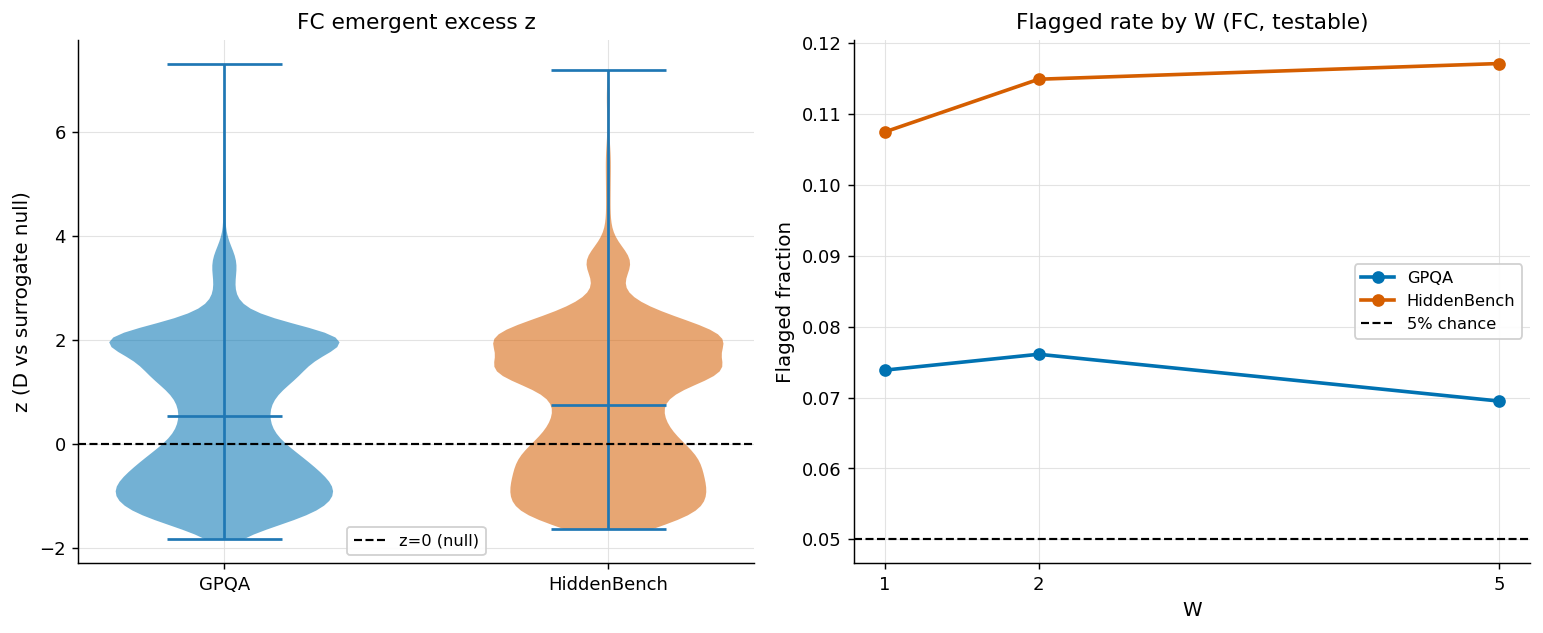

fig2 saved


In [6]:
# Fig 2 — z violin FC + flag rate by W
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
data = [df_rep[(df_rep.dataset==ds)&(df_rep.topology==Z_FLAG_TOPO)&(df_rep.testable)]['z'].dropna()
        for ds in DATASETS]
parts = ax.violinplot(data, positions=[1,2], widths=0.6, showmeans=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(list(DS_COLORS.values())[i]); pc.set_alpha(0.55)
ax.axhline(0, color='black', linestyle='--', lw=1.2, label='z=0 (null)')
ax.set_xticks([1,2]); ax.set_xticklabels([DS_LABELS[d] for d in DATASETS])
ax.set_ylabel('z (D vs surrogate null)')
ax.set_title(f'FC emergent excess z')
ax.legend(fontsize=9)

ax = axes[1]
for ds in DATASETS:
    grp = (df_rep[(df_rep.dataset==ds)&(df_rep.topology==Z_FLAG_TOPO)&(df_rep.testable)]
           .groupby('W')['flagged'].mean().reset_index())
    ax.plot(grp['W'], grp['flagged'], marker='o', color=DS_COLORS[ds],
            label=DS_LABELS[ds], linewidth=2)
ax.axhline(0.05, color='black', linestyle='--', lw=1.2, label='5% chance')
ax.set_xlabel('W'); ax.set_ylabel('Flagged fraction'); ax.set_xticks(W_VALUES)
ax.set_title('Flagged rate by W (FC, testable)')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(EXPORT / 'fig2_excess_fc.png')
plt.show()
print('fig2 saved')

---
## Part 3 — W effect

In [7]:
print('=== W effect: Spearman rho(W,D) task-level, one-sided greater ===')
for ds in DATASETS:
    for topo in TOPOS:
        s = df_task[(df_task.dataset==ds)&(df_task.topology==topo)]
        rho, p = sp_stats.spearmanr(s['W'], s['D'])
        p1 = p/2 if rho>0 else 1-p/2
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: rho={rho:+.3f}  {_sig(p1)} (p1={p1:.3f})')

print()
print('=== Paired Wilcoxon W1->W5 ===')
for ds in DATASETS:
    for topo in TOPOS:
        w1 = df_task[(df_task.dataset==ds)&(df_task.topology==topo)&(df_task.W==1)].set_index('qid')['D']
        w5 = df_task[(df_task.dataset==ds)&(df_task.topology==topo)&(df_task.W==5)].set_index('qid')['D']
        c = w1.index.intersection(w5.index)
        stat, p = sp_stats.wilcoxon(w5[c], w1[c], alternative='greater')
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: W1={w1[c].mean():.3f}  W5={w5[c].mean():.3f}'
              f'  delta={w5[c].mean()-w1[c].mean():+.3f}  {_sig(p)} (p={p:.4f})')

=== W effect: Spearman rho(W,D) task-level, one-sided greater ===
  GPQA         fc   : rho=+0.052  ns (p1=0.301)
  GPQA         star : rho=-0.009  ns (p1=0.537)
  HiddenBench  fc   : rho=+0.187  * (p1=0.028)
  HiddenBench  star : rho=+0.159  ns (p1=0.052)

=== Paired Wilcoxon W1->W5 ===
  GPQA         fc   : W1=0.143  W5=0.147  delta=+0.004  ns (p=0.1972)
  GPQA         star : W1=0.625  W5=0.639  delta=+0.014  ns (p=0.2718)
  HiddenBench  fc   : W1=0.158  W5=0.177  delta=+0.020  ** (p=0.0027)
  HiddenBench  star : W1=0.532  W5=0.565  delta=+0.033  ** (p=0.0010)


---
## Part 4 — Hub analysis

In [8]:
print('=== Hub influence share p_hub ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep['dataset']==ds)&(df_rep['topology']==topo)]
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: hub_p mean={sub["hub_p"].mean():.3f}'
              f'  p(hub>=50%)={(sub["hub_p"]>=0.5).mean():.3f}'
              f'  hub_is_consensus={sub["hub_is_consensus"].mean():.3f}'
              f'  hub_capitulation={sub["hub_capitulation"].mean():.3f}')

print()
print('=== Group accuracy vs 1/M chance (rep-level; == hub final-vote correctness because hub_is_consensus~1.0 -> tautological relabel; task-level test in Part 9) ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep['dataset']==ds)&(df_rep['topology']==topo)]
        frac = sub['hub_correct'].mean()
        # baseline: 1/M
        M = int(sub['M'].mode()[0])
        baseline = 1/M
        n = len(sub)
        k = int(sub['hub_correct'].sum())
        p = sp_stats.binomtest(k, n, baseline, alternative='greater').pvalue
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: hub_correct={frac:.3f}'
              f'  (baseline=1/{M}={baseline:.3f})  {_sig(p)} (p={p:.1e})')

=== Hub influence share p_hub ===
  GPQA         fc   : hub_p mean=0.419  p(hub>=50%)=0.264  hub_is_consensus=1.000  hub_capitulation=0.115
  GPQA         star : hub_p mean=0.788  p(hub>=50%)=0.899  hub_is_consensus=0.998  hub_capitulation=0.175
  HiddenBench  fc   : hub_p mean=0.451  p(hub>=50%)=0.300  hub_is_consensus=0.996  hub_capitulation=0.138
  HiddenBench  star : hub_p mean=0.762  p(hub>=50%)=0.923  hub_is_consensus=0.989  hub_capitulation=0.201

=== Group accuracy vs 1/M chance (rep-level; == hub final-vote correctness because hub_is_consensus~1.0 -> tautological relabel; task-level test in Part 9) ===
  GPQA         fc   : hub_correct=0.422  (baseline=1/4=0.250)  *** (p=1.8e-124)
  GPQA         star : hub_correct=0.423  (baseline=1/4=0.250)  *** (p=4.8e-125)
  HiddenBench  fc   : hub_correct=0.317  (baseline=1/3=0.333)  ns (p=9.9e-01)
  HiddenBench  star : hub_correct=0.299  (baseline=1/3=0.333)  ns (p=1.0e+00)


---
## Part 5 — Hub stability across repetitions (novel analysis)

Does the same agent keep winning the hub role, or is it randomly assigned each rep?

In [9]:
# Hub stability: for each (task, config), compute Herfindahl concentration of hub identities
hub_stab_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W, ds, topo, qid = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id']
    gt   = d['ground_truth']
    reps = d['repetitions']

    rep_results = [analyse_dominance(rep, B=0, seed=0) for rep in reps]  # B=0: skip surrogates
    hubs = [r['hub'] for r in rep_results if r is not None]
    if not hubs:
        continue

    N = reps[0]['N']
    cnts = Counter(hubs)
    p = np.array([cnts.get(i, 0)/len(hubs) for i in range(N)])
    hub_hhi = float(np.dot(p, p))  # raw HHI (not normalized)
    hub_hhi_norm = (hub_hhi - 1/N) / (1 - 1/N)  # normalized like Herfindahl

    # fraction of reps where hub is agent 0 (centre in star) vs distributed
    most_common_hub = cnts.most_common(1)[0]
    dominant_hub_frac = most_common_hub[1] / len(hubs)
    dominant_hub_id   = most_common_hub[0]

    # hub correct: does the most common hub hold the correct answer most often?
    hub_vote_rows = [(r['hub'], reps[i]['trajectory'][-1]['phase_b'][r['hub']]['vote'])
                     for i, r in enumerate(rep_results) if r is not None]
    dominant_hub_votes = [v for (h, v) in hub_vote_rows if h == dominant_hub_id]
    dom_hub_correct_frac = sum(v==gt for v in dominant_hub_votes)/len(dominant_hub_votes) if dominant_hub_votes else np.nan

    hub_stab_rows.append({
        'dataset': ds, 'topology': topo, 'W': W, 'qid': qid,
        'hub_hhi': hub_hhi,
        'hub_hhi_norm': hub_hhi_norm,
        'dominant_hub_frac': dominant_hub_frac,
        'dominant_hub_id': dominant_hub_id,
        'dom_hub_correct_frac': dom_hub_correct_frac,
        'n_reps': len(hubs),
    })

df_stab = pd.DataFrame(hub_stab_rows)
print('=== Hub stability (HHI over hub identities per cell) ===')
print('  HHI_norm=0 -> random; HHI_norm=1 -> same hub always')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_stab[(df_stab.dataset==ds)&(df_stab.topology==topo)]
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: hub_hhi_norm mean={sub["hub_hhi_norm"].mean():.3f}'
              f'  dominant_frac mean={sub["dominant_hub_frac"].mean():.3f}')
print()

print('=== Dominant hub holds correct answer fraction ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_stab[(df_stab.dataset==ds)&(df_stab.topology==topo)].dropna(subset=['dom_hub_correct_frac'])
        M = 4 if ds == 'gpqa' else 3
        baseline = 1/M
        t, p = sp_stats.ttest_1samp(sub['dom_hub_correct_frac'], baseline)
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: dom_hub_correct={sub["dom_hub_correct_frac"].mean():.3f}'
              f'  (baseline={baseline:.3f})  t={t:.2f}  p={p:.4f}')

=== Hub stability (HHI over hub identities per cell) ===
  HHI_norm=0 -> random; HHI_norm=1 -> same hub always
  GPQA         fc   : hub_hhi_norm mean=0.158  dominant_frac mean=0.491
  GPQA         star : hub_hhi_norm mean=0.042  dominant_frac mean=0.349
  HiddenBench  fc   : hub_hhi_norm mean=0.143  dominant_frac mean=0.470
  HiddenBench  star : hub_hhi_norm mean=0.021  dominant_frac mean=0.327

=== Dominant hub holds correct answer fraction ===
  GPQA         fc   : dom_hub_correct=0.405  (baseline=0.250)  t=5.05  p=0.0000
  GPQA         star : dom_hub_correct=0.404  (baseline=0.250)  t=5.49  p=0.0000
  HiddenBench  fc   : dom_hub_correct=0.314  (baseline=0.333)  t=-0.73  p=0.4693
  HiddenBench  star : dom_hub_correct=0.291  (baseline=0.333)  t=-2.04  p=0.0440


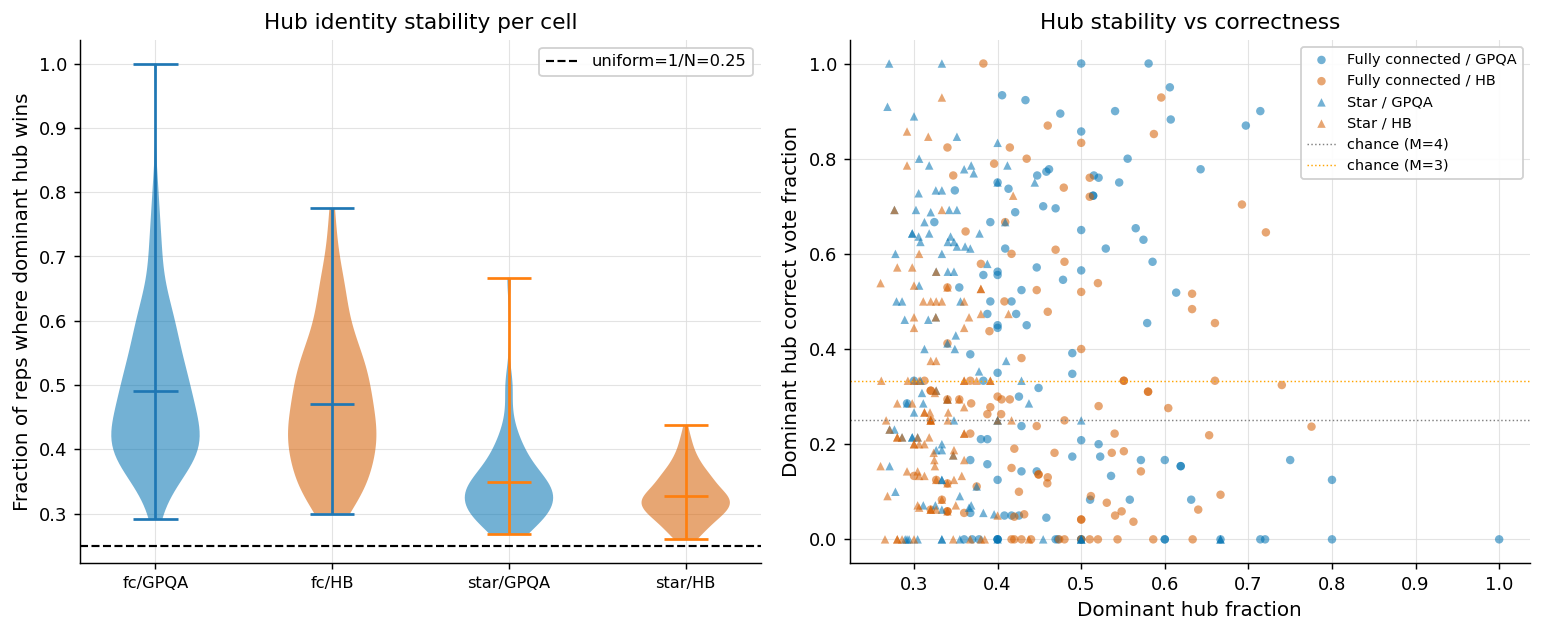

fig3 saved


In [10]:
# Fig 3 — hub stability violin + dominant hub correct fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for topo in TOPOS:
    data = [df_stab[(df_stab.dataset==ds)&(df_stab.topology==topo)]['dominant_hub_frac'].values
            for ds in DATASETS]
    positions = [1,2] if topo == 'fc' else [3,4]
    parts = ax.violinplot(data, positions=positions, widths=0.5, showmeans=True)
    for pc, ds in zip(parts['bodies'], DATASETS):
        pc.set_facecolor(DS_COLORS[ds]); pc.set_alpha(0.55)

N = 4
ax.axhline(1/N, color='black', linestyle='--', lw=1.2, label=f'uniform=1/N={1/N:.2f}')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels([f'fc/{ABBR[d]}' for d in DATASETS] +
                   [f'star/{ABBR[d]}' for d in DATASETS], fontsize=9)
ax.set_ylabel('Fraction of reps where dominant hub wins')
ax.set_title('Hub identity stability per cell')
ax.legend(fontsize=9)

ax = axes[1]
for topo in TOPOS:
    for ds in DATASETS:
        sub = df_stab[(df_stab.dataset==ds)&(df_stab.topology==topo)].dropna(subset=['dom_hub_correct_frac'])
        ax.scatter(sub['dominant_hub_frac'], sub['dom_hub_correct_frac'],
                   color=DS_COLORS[ds], marker=('o' if topo=='fc' else '^'),
                   s=22, alpha=0.55,
                   label=f'{T_LABELS[topo]} / {ABBR[ds]}', edgecolors='none')

ax.axhline(1/4, color='grey', lw=0.8, linestyle=':', label='chance (M=4)')
ax.axhline(1/3, color='orange', lw=0.8, linestyle=':', label='chance (M=3)')
ax.set_xlabel('Dominant hub fraction')
ax.set_ylabel('Dominant hub correct vote fraction')
ax.set_title('Hub stability vs correctness')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'fig3_hub_stability.png')
plt.show()
print('fig3 saved')

---
## Part 6 — Dominance vs Accuracy

In [11]:
print('=== Spearman: D_mean vs task accuracy (cell-level) ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df[(df.dataset==ds)&(df.topology==topo)].dropna(subset=['D_mean','accuracy'])
        r, p = sp_stats.spearmanr(sub['D_mean'], sub['accuracy'])
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: rho={r:+.3f}  {_sig(p)} (p={p:.4f})  n={len(sub)}')

print()
print('=== Per-rep D: correct vs incorrect (MWU) ===')
for ds in DATASETS:
    for topo in TOPOS:
        s = df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)].dropna(subset=['correct'])
        dc = s[s.correct==True]['D']; di = s[s.correct==False]['D']
        if len(dc)<2 or len(di)<2: continue
        stat, p = sp_stats.mannwhitneyu(dc, di, alternative='two-sided')
        sign = '+' if dc.mean()>di.mean() else '-'
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: D|correct={dc.mean():.3f}'
              f'  D|incorrect={di.mean():.3f}  (delta={dc.mean()-di.mean():+.3f})'
              f'  {_sig(p)} (p={p:.1e})')

print()
print('=== hub_is_consensus vs hub_correct: does leadership predict correctness? ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)]
        # When hub IS consensus (its vote became group answer), is it correct more often?
        is_con = sub[sub['hub_is_consensus']==True]['hub_correct'].mean()
        not_con = sub[sub['hub_is_consensus']==False]['hub_correct'].mean()
        ct = pd.crosstab(sub['hub_is_consensus'].astype(int), sub['hub_correct'].astype(int))
        if ct.shape == (2,2):
            chi2, p, _, _ = sp_stats.chi2_contingency(ct)
        else:
            p = float('nan')
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: hub_is_consensus->hub_correct={is_con:.3f}'
              f'  vs not={not_con:.3f}  {_sig(p)} (p={p:.4f})')

=== Spearman: D_mean vs task accuracy (cell-level) ===
  GPQA         fc   : rho=+0.043  ns (p=0.6619)  n=105
  GPQA         star : rho=-0.015  ns (p=0.8821)  n=105
  HiddenBench  fc   : rho=+0.367  *** (p=0.0001)  n=105
  HiddenBench  star : rho=-0.004  ns (p=0.9651)  n=105

=== Per-rep D: correct vs incorrect (MWU) ===
  GPQA         fc   : D|correct=0.157  D|incorrect=0.148  (delta=+0.008)  ns (p=1.7e-01)
  GPQA         star : D|correct=0.629  D|incorrect=0.590  (delta=+0.039)  *** (p=8.2e-04)
  HiddenBench  fc   : D|correct=0.219  D|incorrect=0.150  (delta=+0.069)  *** (p=1.1e-30)
  HiddenBench  star : D|correct=0.531  D|incorrect=0.559  (delta=-0.029)  ns (p=6.6e-02)

=== hub_is_consensus vs hub_correct: does leadership predict correctness? ===
  GPQA         fc   : hub_is_consensus->hub_correct=0.422  vs not=1.000  ns (p=0.8752)
  GPQA         star : hub_is_consensus->hub_correct=0.423  vs not=0.667  ns (p=0.4266)
  HiddenBench  fc   : hub_is_consensus->hub_correct=0.318  vs not=

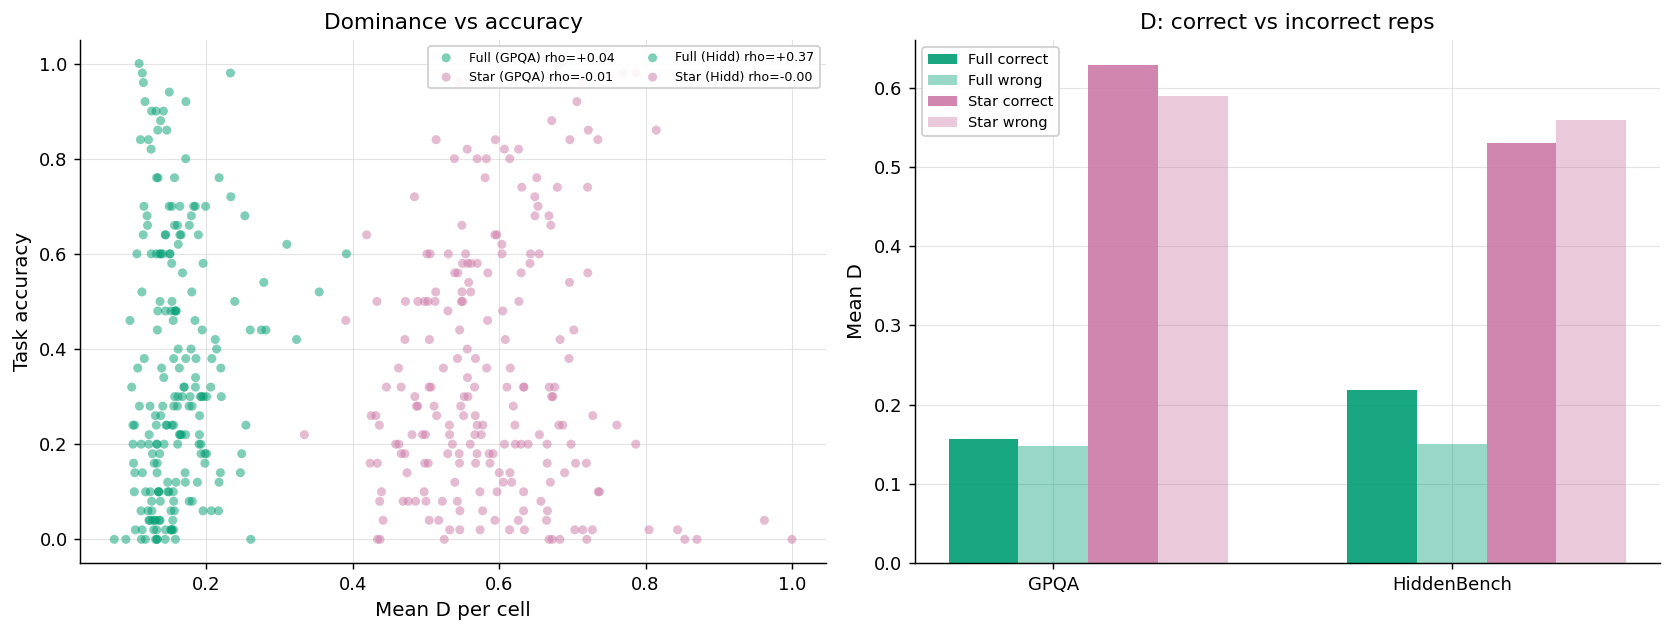

fig4 saved


In [12]:
# Fig 4 — D vs accuracy scatter + correct vs incorrect D
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for ds in DATASETS:
    sub = df[df['dataset']==ds].dropna(subset=['D_mean','accuracy'])
    for topo in TOPOS:
        s = sub[sub['topology']==topo]
        rho, p = sp_stats.spearmanr(s['D_mean'], s['accuracy'])
        ax.scatter(s['D_mean'], s['accuracy'], color=T_COLORS[topo],
                   s=25, alpha=0.5, edgecolors='none',
                   label=f'{T_LABELS[topo][:4]} ({DS_LABELS[ds][:4]}) rho={rho:+.2f}')
ax.set_xlabel('Mean D per cell')
ax.set_ylabel('Task accuracy')
ax.set_title('Dominance vs accuracy')
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
width = 0.35
x = np.arange(len(DATASETS))
for i, topo in enumerate(TOPOS):
    dc_means = [df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)&(df_rep.correct==True)]['D'].mean()
                for ds in DATASETS]
    di_means = [df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)&(df_rep.correct==False)]['D'].mean()
                for ds in DATASETS]
    ax.bar(x + (i-0.5)*width, dc_means, width/2, label=f'{T_LABELS[topo][:4]} correct',
           color=T_COLORS[topo], alpha=0.9)
    ax.bar(x + i*width,       di_means, width/2, label=f'{T_LABELS[topo][:4]} wrong',
           color=T_COLORS[topo], alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels([DS_LABELS[d] for d in DATASETS])
ax.set_ylabel('Mean D'); ax.set_title('D: correct vs incorrect reps')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'fig4_D_accuracy.png')
plt.show()
print('fig4 saved')

---
## Part 7 — Cross-motif: Dominance × Bistability

In [13]:
from src.metrics.bistability import analyse_bistability

bist_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d = json.loads(f.read_text())
    W, ds, topo, qid, gt = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id'], d['ground_truth']
    r = analyse_bistability(d['repetitions'], seed=42)
    bist_rows.append({'dataset':ds,'topology':topo,'W':W,'qid':qid,
                      'n_eff':r['n_eff'],'cramers_v':r['cramers_v'],'label':r['label']})

df_bist = pd.DataFrame(bist_rows)
df_cross = df.merge(df_bist, on=['dataset','topology','W','qid'])

print('=== Spearman: D_mean vs N_eff (per dataset) ===')
for ds in DATASETS:
    sub = df_cross[df_cross['dataset']==ds].dropna(subset=['D_mean','n_eff'])
    r, p = sp_stats.spearmanr(sub['D_mean'], sub['n_eff'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:+.3f}  {_sig(p)} (p={p:.4f})  n={len(sub)}')

print()
print('=== D_mean by bistability label ===')
for lbl in ['monostable','multistable','stochastic']:
    sub = df_cross[df_cross['label']==lbl]['D_mean'].dropna()
    print(f'  {lbl:14s}: mean={sub.mean():.3f}  n={len(sub)}')

# MWU
mono_d = df_cross[df_cross['label']=='monostable']['D_mean'].dropna()
mult_d = df_cross[df_cross['label']=='multistable']['D_mean'].dropna()
stoc_d = df_cross[df_cross['label']=='stochastic']['D_mean'].dropna()
print()
for a_lbl, a_v, b_lbl, b_v in [
    ('mono', mono_d, 'multi', mult_d),
    ('mono', mono_d, 'stoch', stoc_d),
    ('multi', mult_d, 'stoch', stoc_d),
]:
    if len(a_v)<2 or len(b_v)<2: continue
    stat, p = sp_stats.mannwhitneyu(a_v, b_v, alternative='two-sided')
    print(f'  {a_lbl} vs {b_lbl}: {_sig(p)} (p={p:.4f})')

=== Spearman: D_mean vs N_eff (per dataset) ===
  GPQA        : rho=-0.070  ns (p=0.3140)  n=210
  HiddenBench : rho=+0.012  ns (p=0.8617)  n=210

=== D_mean by bistability label ===
  monostable    : mean=0.411  n=90
  multistable   : mean=0.375  n=176
  stochastic    : mean=0.355  n=154

  mono vs multi: ns (p=0.9416)
  mono vs stoch: ns (p=0.4205)
  multi vs stoch: ns (p=0.2023)


---
## Part 8 — Conversion structure: do high-D reps have concentrated conversions?

In [14]:
# For each rep, compute: n_conversions, total_weight, max_single_source_weight/total
conv_struct_rows = []
for f in sorted(BASE.glob('**/*.json')):
    d = json.loads(f.read_text())
    W, ds, topo, qid, gt = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id'], d['ground_truth']
    for rep_idx, rep in enumerate(d['repetitions']):
        G = _influence_graph(rep)
        total = G.sum()
        if total == 0:
            continue
        per_source = G.sum(axis=1)  # influence generated by each source agent
        n_sources_active = int((per_source > 0).sum())
        max_source_frac = float(per_source.max() / total)
        conv_struct_rows.append({
            'dataset': ds, 'topology': topo, 'W': W, 'qid': qid, 'rep_idx': rep_idx,
            'total_conv_weight': float(total),
            'n_sources_active': n_sources_active,
            'max_source_frac': max_source_frac,
            'correct': rep.get('correct'),
        })

df_conv = pd.DataFrame(conv_struct_rows)
df_rep_aug = df_rep.merge(df_conv, on=['dataset','topology','W','qid','rep_idx'], how='left')

print('=== D vs max_source_frac (concentration of conversions on one source) ===')
for ds in DATASETS:
    sub = df_rep_aug[df_rep_aug['dataset']==ds].dropna(subset=['D','max_source_frac'])
    r, p = sp_stats.spearmanr(sub['D'], sub['max_source_frac'])
    print(f'  {DS_LABELS[ds]:12s}: rho={r:+.3f}  {_sig(p)} (p={p:.4f})  n={len(sub)}')

print()
print('=== D vs total_conv_weight ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep_aug[(df_rep_aug.dataset==ds)&(df_rep_aug.topology==topo)].dropna(subset=['D','total_conv_weight'])
        r, p = sp_stats.spearmanr(sub['D'], sub['total_conv_weight'])
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: rho={r:+.3f}  {_sig(p)} (p={p:.4f})')

print()
print('=== n_sources_active by topology (fewer in star?) ===')
for topo in TOPOS:
    sub = df_rep_aug[df_rep_aug.topology==topo]['n_sources_active']
    print(f'  {topo:5s}: mean={sub.mean():.2f}  median={sub.median():.1f}')

=== D vs max_source_frac (concentration of conversions on one source) ===
  GPQA        : rho=+0.936  *** (p=0.0000)  n=7943
  HiddenBench : rho=+0.953  *** (p=0.0000)  n=9858

=== D vs total_conv_weight ===
  GPQA         fc   : rho=-0.335  *** (p=0.0000)
  GPQA         star : rho=-0.556  *** (p=0.0000)
  HiddenBench  fc   : rho=-0.377  *** (p=0.0000)
  HiddenBench  star : rho=-0.497  *** (p=0.0000)

=== n_sources_active by topology (fewer in star?) ===
  fc   : mean=3.34  median=3.0
  star : mean=2.57  median=3.0


In [15]:
# Summary table
print('=== DOMINANCE SUMMARY TABLE ===')
print()
print(f'Total reps: {df["n_reps"].sum():,}  |  valid: {df["n_valid"].sum():,}'
      f'  |  testable FC: {df[df.topology==Z_FLAG_TOPO]["n_testable"].sum():,}')
print()
print('Mean raw D:')
for ds in DATASETS:
    for topo in TOPOS:
        sub = df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)]['D']
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: {sub.mean():.3f}  (star/fc ratio: '
              + (f'{df_rep[(df_rep.dataset==ds)&(df_rep.topology=="star")]["D"].mean()/df_rep[(df_rep.dataset==ds)&(df_rep.topology=="fc")]["D"].mean():.1f}x)' if topo=='star' else 'see star)'))
print()
print('FC emergent excess z (pooled):')
for ds in DATASETS:
    z = df_rep[(df_rep.dataset==ds)&(df_rep.topology==Z_FLAG_TOPO)&(df_rep.testable)]['z'].dropna()
    stat, p = sp_stats.wilcoxon(z, alternative='greater')
    print(f'  {DS_LABELS[ds]:12s}: mean_z={z.mean():+.3f}  flagged={z[z>0].shape[0]/len(z):.3f}  {_sig(p)}')

=== DOMINANCE SUMMARY TABLE ===

Total reps: 21,000  |  valid: 17,801  |  testable FC: 6,917

Mean raw D:
  GPQA         fc   : 0.152  (star/fc ratio: see star)
  GPQA         star : 0.606  (star/fc ratio: 4.0x)
  HiddenBench  fc   : 0.172  (star/fc ratio: see star)
  HiddenBench  star : 0.551  (star/fc ratio: 3.2x)

FC emergent excess z (pooled):
  GPQA        : mean_z=+0.535  flagged=0.555  ***
  HiddenBench : mean_z=+0.750  flagged=0.621  ***


---
## Part 9 — Task-level corrections (n~35) and BH-FDR

All tests below aggregate reps to one value per task (unit = task) to avoid pseudo-replication, then apply Benjamini-Hochberg FDR within each family of related tests.

In [16]:
fam = {}

print('=== TASK-LEVEL (n~35): FC emergent excess z>0 (one-sample across tasks) ===')
for ds in DATASETS:
    s = df_rep[(df_rep.dataset==ds)&(df_rep.topology=='fc')&(df_rep.testable)]
    per_task = s.groupby('qid')['z'].mean().values
    stat, pw, n = task_one_sample_wilcoxon(per_task, null=0.0)
    k, ns, ps = task_sign_test(per_task, null=0.0, alternative='greater')
    print(f'  {DS_LABELS[ds]:12s}: mean_task_z={np.nanmean(per_task):+.3f}  pos={k}/{ns}'
          f'  sign p={ps:.2e}  wilcoxon p={pw:.2e}  n={n}')

print()
print('=== TASK-LEVEL (n~35): FC flagged fraction vs 5% [flag-rate family] ===')
for ds in DATASETS:
    s = df_rep[(df_rep.dataset==ds)&(df_rep.topology=='fc')&(df_rep.testable)]
    per_task = s.groupby('qid')['flagged'].mean().values
    stat, p, n = task_one_sample_wilcoxon(per_task, null=0.05)
    fam.setdefault('flag_rate', []).append((DS_LABELS[ds], p))
    print(f'  {DS_LABELS[ds]:12s}: mean_task_flag={np.nanmean(per_task):.3f}  vs 0.05  p={p:.2e}  n={n}')

=== TASK-LEVEL (n~35): FC emergent excess z>0 (one-sample across tasks) ===
  GPQA        : mean_task_z=+0.536  pos=35/35  sign p=2.91e-11  wilcoxon p=5.82e-11  n=35
  HiddenBench : mean_task_z=+0.755  pos=35/35  sign p=2.91e-11  wilcoxon p=5.82e-11  n=35

=== TASK-LEVEL (n~35): FC flagged fraction vs 5% [flag-rate family] ===
  GPQA        : mean_task_flag=0.072  vs 0.05  p=6.07e-03  n=35
  HiddenBench : mean_task_flag=0.114  vs 0.05  p=8.71e-06  n=35


In [17]:
print('=== TASK-LEVEL (n~35): group accuracy vs 1/M chance ===')
print('(relabels tautological hub-correctness; hub_is_consensus~1.0 -> hub-correct == group-correct)')
for ds in DATASETS:
    for topo in TOPOS:
        s = df[(df.dataset==ds)&(df.topology==topo)]
        per_task = s.groupby('qid').apply(lambda x:(x['accuracy']-1.0/x['M']).mean(),
                                          include_groups=False).values
        stat_g, pg = sp_stats.wilcoxon(per_task, alternative='greater')
        stat, p2, n = task_one_sample_wilcoxon(per_task, null=0.0)
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: mean(acc-1/M)={np.mean(per_task):+.3f}'
              f'  one-sided p={pg:.4f}  two-sided p={p2:.4f}  n={n}')

=== TASK-LEVEL (n~35): group accuracy vs 1/M chance ===
(relabels tautological hub-correctness; hub_is_consensus~1.0 -> hub-correct == group-correct)
  GPQA         fc   : mean(acc-1/M)=+0.157  one-sided p=0.0035  two-sided p=0.0070  n=35
  GPQA         star : mean(acc-1/M)=+0.157  one-sided p=0.0035  two-sided p=0.0070  n=35
  HiddenBench  fc   : mean(acc-1/M)=-0.022  one-sided p=0.8546  two-sided p=0.2907  n=35
  HiddenBench  star : mean(acc-1/M)=-0.038  one-sided p=0.9411  two-sided p=0.1177  n=35


In [18]:
print('=== TASK-LEVEL (n~35): dominant-hub-correct vs 1/M [dominant-hub-correct family] ===')
print('(non-tautological analogue: does the recurring dominant hub hold the correct answer?)')
Mq = df.groupby('qid')['M'].first()
for ds in DATASETS:
    for topo in TOPOS:
        s = df_stab[(df_stab.dataset==ds)&(df_stab.topology==topo)].dropna(subset=['dom_hub_correct_frac'])
        g = s.groupby('qid')['dom_hub_correct_frac'].mean()
        diff = (g - 1.0/Mq.loc[g.index]).values
        stat, p, n = task_one_sample_wilcoxon(diff, null=0.0)
        fam.setdefault('dom_hub_correct', []).append((f'{DS_LABELS[ds]}/{topo}', p))
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: dom_hub_correct={g.mean():.3f}'
              f'  mean(diff)={np.mean(diff):+.3f}  p={p:.4f}  n={n}')

=== TASK-LEVEL (n~35): dominant-hub-correct vs 1/M [dominant-hub-correct family] ===
(non-tautological analogue: does the recurring dominant hub hold the correct answer?)
  GPQA         fc   : dom_hub_correct=0.405  mean(diff)=+0.153  p=0.0122  n=35
  GPQA         star : dom_hub_correct=0.404  mean(diff)=+0.152  p=0.0084  n=35
  HiddenBench  fc   : dom_hub_correct=0.314  mean(diff)=-0.009  p=0.5436  n=35
  HiddenBench  star : dom_hub_correct=0.291  mean(diff)=-0.032  p=0.1449  n=35


In [19]:
print('=== TASK-LEVEL (n~35): W1->W5 paired Wilcoxon (one-sided greater) [W-effect family] ===')
for ds in DATASETS:
    for topo in TOPOS:
        w1 = df_task[(df_task.dataset==ds)&(df_task.topology==topo)&(df_task.W==1)].set_index('qid')['D']
        w5 = df_task[(df_task.dataset==ds)&(df_task.topology==topo)&(df_task.W==5)].set_index('qid')['D']
        c = w1.index.intersection(w5.index)
        stat, p = sp_stats.wilcoxon(w5[c], w1[c], alternative='greater')
        fam.setdefault('W_effect', []).append((f'{DS_LABELS[ds]}/{topo}', p))
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: delta={w5[c].mean()-w1[c].mean():+.3f}  p={p:.4f}  n={len(c)}')

=== TASK-LEVEL (n~35): W1->W5 paired Wilcoxon (one-sided greater) [W-effect family] ===
  GPQA         fc   : delta=+0.004  p=0.1972  n=35
  GPQA         star : delta=+0.014  p=0.2718  n=35
  HiddenBench  fc   : delta=+0.020  p=0.0027  n=35
  HiddenBench  star : delta=+0.033  p=0.0010  n=35


In [20]:
print('=== TASK-LEVEL (n~35): D correct vs incorrect (task-paired Wilcoxon) [D-corr-vs-incorrect family] ===')
for ds in DATASETS:
    for topo in TOPOS:
        s = df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)].dropna(subset=['correct'])
        corr = s[s.correct==True].groupby('qid')['D'].mean()
        inc  = s[s.correct==False].groupby('qid')['D'].mean()
        c = corr.index.intersection(inc.index)
        stat, p, md, n = task_paired_wilcoxon(corr[c].values, inc[c].values)
        d = float((corr[c]-inc[c]).mean())
        fam.setdefault('D_corr_inc', []).append((f'{DS_LABELS[ds]}/{topo}', p))
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: d={d:+.3f}  median_diff={md:+.3f}  p={p:.4f}  n={n}')

=== TASK-LEVEL (n~35): D correct vs incorrect (task-paired Wilcoxon) [D-corr-vs-incorrect family] ===
  GPQA         fc   : d=+0.025  median_diff=+0.017  p=0.0443  n=33
  GPQA         star : d=+0.003  median_diff=+0.031  p=0.8132  n=34
  HiddenBench  fc   : d=+0.059  median_diff=+0.053  p=0.0001  n=35
  HiddenBench  star : d=-0.051  median_diff=-0.056  p=0.0101  n=35


In [21]:
print('=== TASK-LEVEL (n~35): D vs accuracy Spearman [D-accuracy family] ===')
for ds in DATASETS:
    for topo in TOPOS:
        dt = df_rep[(df_rep.dataset==ds)&(df_rep.topology==topo)].groupby('qid')['D'].mean()
        at = df[(df.dataset==ds)&(df.topology==topo)].groupby('qid')['accuracy'].mean()
        c = dt.index.intersection(at.index)
        rho, p, n = task_spearman(dt[c].values, at[c].values)
        fam.setdefault('D_accuracy', []).append((f'{DS_LABELS[ds]}/{topo}', p))
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}: rho={rho:+.3f}  p={p:.4f}  n={n}')

print()
print('=== TASK-LEVEL (n~35): D vs max_source_frac Spearman (conversion structure) ===')
for ds in DATASETS:
    m = df_rep_aug[df_rep_aug.dataset==ds].dropna(subset=['D','max_source_frac'])
    dt = m.groupby('qid')['D'].mean()
    st = m.groupby('qid')['max_source_frac'].mean()
    rho, p, n = task_spearman(dt.values, st.values)
    print(f'  {DS_LABELS[ds]:12s}: rho={rho:+.3f}  p={p:.4f}  n={n}')

print()
print('=== FC hub influence share (~44%) ===')
for ds in DATASETS:
    v = df_rep[(df_rep.dataset==ds)&(df_rep.topology=='fc')]['hub_p'].mean()
    print(f'  {DS_LABELS[ds]:12s} fc: hub_p mean={v:.3f}')

=== TASK-LEVEL (n~35): D vs accuracy Spearman [D-accuracy family] ===
  GPQA         fc   : rho=+0.036  p=0.8392  n=35
  GPQA         star : rho=-0.017  p=0.9211  n=35
  HiddenBench  fc   : rho=+0.443  p=0.0077  n=35
  HiddenBench  star : rho=+0.005  p=0.9783  n=35

=== TASK-LEVEL (n~35): D vs max_source_frac Spearman (conversion structure) ===
  GPQA        : rho=+0.852  p=0.0000  n=35
  HiddenBench : rho=+0.838  p=0.0000  n=35

=== FC hub influence share (~44%) ===
  GPQA         fc: hub_p mean=0.419
  HiddenBench  fc: hub_p mean=0.451


In [22]:
print('=== BH-FDR within families (q<0.05 survives) ===')
for name in ['flag_rate','W_effect','dom_hub_correct','D_accuracy','D_corr_inc']:
    items = fam.get(name, [])
    if not items:
        continue
    labels = [l for l, _ in items]
    ps = [p for _, p in items]
    q, rej = bh_fdr(ps)
    print(f'-- {name} (n={len(ps)}) --')
    for l, p, qq, rj in zip(labels, ps, q, rej):
        print(f'   {l:20s} p={p:.2e}  q={qq:.2e}  {"SURVIVES" if rj else "ns"}')

=== BH-FDR within families (q<0.05 survives) ===
-- flag_rate (n=2) --
   GPQA                 p=6.07e-03  q=6.07e-03  SURVIVES
   HiddenBench          p=8.71e-06  q=1.74e-05  SURVIVES
-- W_effect (n=4) --
   GPQA/fc              p=1.97e-01  q=2.63e-01  ns
   GPQA/star            p=2.72e-01  q=2.72e-01  ns
   HiddenBench/fc       p=2.67e-03  q=5.34e-03  SURVIVES
   HiddenBench/star     p=1.04e-03  q=4.18e-03  SURVIVES
-- dom_hub_correct (n=4) --
   GPQA/fc              p=1.22e-02  q=2.44e-02  SURVIVES
   GPQA/star            p=8.36e-03  q=2.44e-02  SURVIVES
   HiddenBench/fc       p=5.44e-01  q=5.44e-01  ns
   HiddenBench/star     p=1.45e-01  q=1.93e-01  ns
-- D_accuracy (n=4) --
   GPQA/fc              p=8.39e-01  q=9.78e-01  ns
   GPQA/star            p=9.21e-01  q=9.78e-01  ns
   HiddenBench/fc       p=7.72e-03  q=3.09e-02  SURVIVES
   HiddenBench/star     p=9.78e-01  q=9.78e-01  ns
-- D_corr_inc (n=4) --
   GPQA/fc              p=4.43e-02  q=5.91e-02  ns
   GPQA/star            p=8